## biosnap结果分析

In [1]:
import pandas as pd
import numpy as np
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve, precision_recall_curve, f1_score, accuracy_score, matthews_corrcoef
import matplotlib.pyplot as plt

In [2]:
# 定义函数：计算 AUC、AUPR 和分类指标
def calculate_metrics(file_path):
    # 读取文件
    data = pd.read_csv(file_path)
    y_true = data['classification_label']
    y_pred = data['predicted_binary_interaction']
    
    # 计算 AUC 和 AUPR
    auc = roc_auc_score(y_true, y_pred)
    aupr = average_precision_score(y_true, y_pred)
    
    # 初始化变量
    thresholds = np.linspace(0, 1, 1000)  # 在 [0, 1] 范围内生成 1000 个阈值
    best_f1 = 0
    best_threshold = 0
    best_metrics = {}
    
    # 遍历每个阈值，计算分类指标
    for threshold in thresholds:
        y_pred_binary = (y_pred >= threshold).astype(int)
        tp = np.sum((y_pred_binary == 1) & (y_true == 1))
        tn = np.sum((y_pred_binary == 0) & (y_true == 0))
        fp = np.sum((y_pred_binary == 1) & (y_true == 0))
        fn = np.sum((y_pred_binary == 0) & (y_true == 1))
        
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
        accuracy = (tp + tn) / (tp + tn + fp + fn)
        mcc = matthews_corrcoef(y_true, y_pred_binary) if (tp + fp) > 0 and (tp + fn) > 0 and (tn + fp) > 0 and (tn + fn) > 0 else 0
        
        # 更新最佳 F1 分数及对应的阈值和指标
        if f1 > best_f1:
            best_f1 = f1
            best_threshold = threshold
            best_metrics = {
                'accuracy': accuracy,
                'f1': f1,
                'precision': precision,
                'recall': recall,
                'mcc': mcc,
                'tp': tp,
                'tn': tn,
                'fp': fp,
                'fn': fn
            }
    
    # 计算 ROC 曲线和 PR 曲线
    fpr, tpr, roc_thresholds = roc_curve(y_true, y_pred)
    precision, recall, pr_thresholds = precision_recall_curve(y_true, y_pred)
    
    return {
        'auc': auc,
        'aupr': aupr,
        'best_threshold': best_threshold,
        'best_metrics': best_metrics,
        'roc_curve': (fpr, tpr),
        'pr_curve': (precision, recall)
    }

# 定义函数：绘制 ROC 和 PR 曲线
def plot_curves(results, output_path):
    plt.figure(figsize=(12, 6))
    
    # 绘制 ROC 曲线
    plt.subplot(1, 2, 1)
    for i, result in enumerate(results):
        fpr, tpr = result['roc_curve']
        plt.plot(fpr, tpr, label=f'File {i+1} (AUC={result["auc"]:.3f})')
    plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend()
    
    # 绘制 PR 曲线
    plt.subplot(1, 2, 2)
    for i, result in enumerate(results):
        precision, recall = result['pr_curve']
        plt.plot(recall, precision, label=f'File {i+1} (AUPR={result["aupr"]:.3f})')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curve')
    plt.legend()
    
    # 保存图像
    plt.tight_layout()
    plt.savefig(output_path)
    plt.show()


## random

Results for ./random_RUN_1/test_prediction_seed3.csv:
AUC: 0.9188, AUPR: 0.9129
Best Threshold: 0.2843
Metrics at Best Threshold: {'accuracy': 0.853267795375933, 'f1': 0.8579985905567301, 'precision': 0.8316256830601093, 'recall': 0.886098981077147, 'mcc': 0.7080473560191956, 'tp': 2435, 'tn': 2252, 'fp': 493, 'fn': 313}

Results for ./random_RUN_2/test_prediction_seed3.csv:
AUC: 0.9214, AUPR: 0.9144
Best Threshold: 0.7397
Metrics at Best Threshold: {'accuracy': 0.8632805388676498, 'f1': 0.8608486196034835, 'precision': 0.8769346923367308, 'recall': 0.8453420669577875, 'mcc': 0.7270388369844355, 'tp': 2323, 'tn': 2419, 'fp': 326, 'fn': 425}

Results for ./random_RUN_3/test_prediction_seed3.csv:
AUC: 0.9244, AUPR: 0.9244
Best Threshold: 0.6717
Metrics at Best Threshold: {'accuracy': 0.8587292918259604, 'f1': 0.8592673195502357, 'precision': 0.85647143890094, 'recall': 0.8620815138282387, 'mcc': 0.7174728968743412, 'tp': 2369, 'tn': 2348, 'fp': 397, 'fn': 379}

Results for ./random_RUN_4

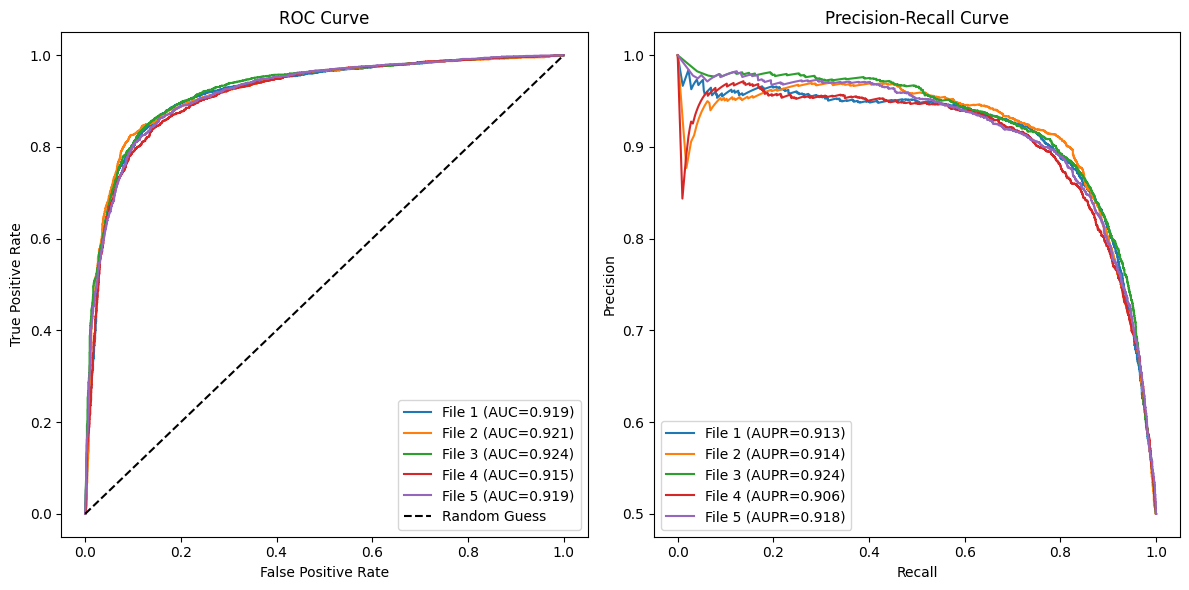

In [3]:
# 主程序
file_paths = [
    './random_RUN_1/test_prediction_seed3.csv',
    './random_RUN_2/test_prediction_seed3.csv',
    './random_RUN_3/test_prediction_seed3.csv',
    './random_RUN_4/test_prediction_seed3.csv',
    './random_RUN_5/test_prediction_seed3.csv'
]  # 替换为实际文件路径
results = []

# 存储每次运行的指标
auc_list = []
aupr_list = []
f1_list = []
accuracy_list = []
precision_list = []
recall_list = []
mcc_list = []

for file_path in file_paths:
    result = calculate_metrics(file_path)
    results.append(result)
    
    # 提取指标
    auc_list.append(result['auc'])
    aupr_list.append(result['aupr'])
    f1_list.append(result['best_metrics']['f1'])
    accuracy_list.append(result['best_metrics']['accuracy'])
    precision_list.append(result['best_metrics']['precision'])
    recall_list.append(result['best_metrics']['recall'])
    mcc_list.append(result['best_metrics']['mcc'])
    
    # 打印每次运行的结果
    print(f"Results for {file_path}:")
    print(f"AUC: {result['auc']:.4f}, AUPR: {result['aupr']:.4f}")
    print(f"Best Threshold: {result['best_threshold']:.4f}")
    print(f"Metrics at Best Threshold: {result['best_metrics']}")
    print()

# 计算均值和标准差
metrics_summary = {
    'AUC': (np.mean(auc_list), np.std(auc_list)),
    'AUPR': (np.mean(aupr_list), np.std(aupr_list)),
    'F1': (np.mean(f1_list), np.std(f1_list)),
    'Accuracy': (np.mean(accuracy_list), np.std(accuracy_list)),
    'Precision': (np.mean(precision_list), np.std(precision_list)),
    'Recall': (np.mean(recall_list), np.std(recall_list)),
    'MCC': (np.mean(mcc_list), np.std(mcc_list))
}

# 打印均值和标准差
print("\nSummary of Metrics (Mean ± Std):")
for metric, (mean, std) in metrics_summary.items():
    print(f"{metric}: {mean:.4f} ± {std:.4f}")

# 绘制曲线
plot_curves(results, 'roc_pr_curves.png')

## protein

Results for ./protein_RUN_1/test_prediction_seed3.csv:
AUC: 0.8723, AUPR: 0.8919
Best Threshold: 0.0160
Metrics at Best Threshold: {'accuracy': 0.7839220864971937, 'f1': 0.8215405589638718, 'precision': 0.7629779691061028, 'recall': 0.8898405197873597, 'mcc': 0.5623470160905321, 'tp': 3013, 'tn': 1736, 'fp': 936, 'fn': 373}

Results for ./protein_RUN_2/test_prediction_seed3.csv:
AUC: 0.8774, AUPR: 0.8980
Best Threshold: 0.2813
Metrics at Best Threshold: {'accuracy': 0.801419610432486, 'f1': 0.8217513705734182, 'precision': 0.8245614035087719, 'recall': 0.818960425280567, 'mcc': 0.5976273646490156, 'tp': 2773, 'tn': 2082, 'fp': 590, 'fn': 613}

Results for ./protein_RUN_3/test_prediction_seed3.csv:
AUC: 0.8776, AUPR: 0.8979
Best Threshold: 0.0891
Metrics at Best Threshold: {'accuracy': 0.7969626939584021, 'f1': 0.8240846681922197, 'precision': 0.7989462007764836, 'recall': 0.8508564678086238, 'mcc': 0.5862193305706763, 'tp': 2881, 'tn': 1947, 'fp': 725, 'fn': 505}

Results for ./protein

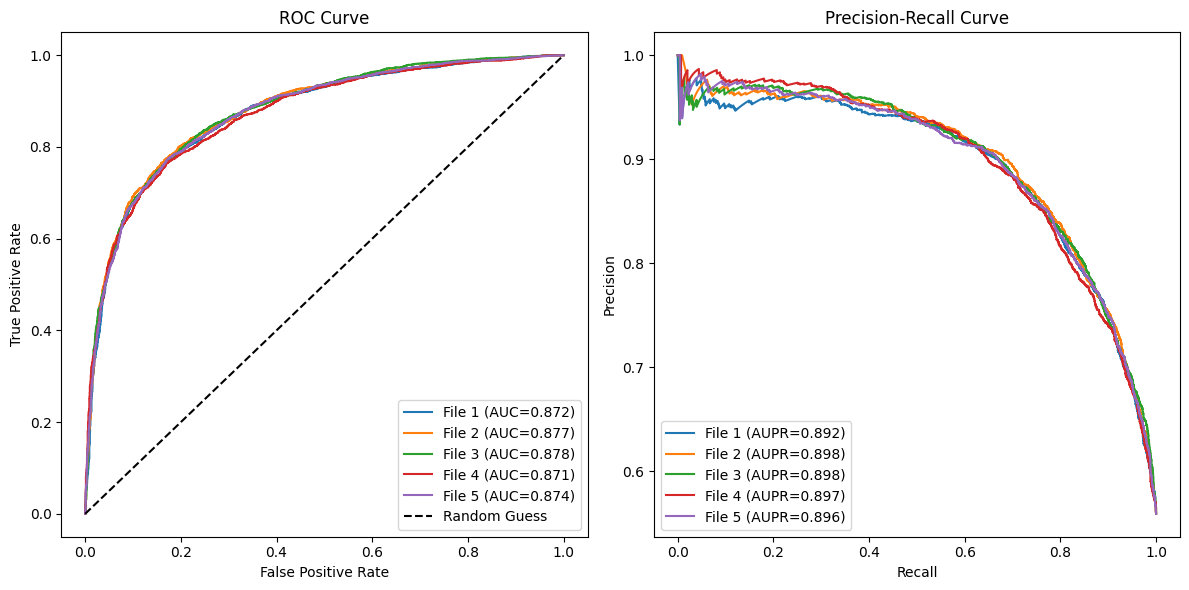

In [4]:
# 主程序
file_paths = [
    './protein_RUN_1/test_prediction_seed3.csv',
    './protein_RUN_2/test_prediction_seed3.csv',
    './protein_RUN_3/test_prediction_seed3.csv',
    './protein_RUN_4/test_prediction_seed3.csv',
    './protein_RUN_5/test_prediction_seed3.csv'
]  # 替换为实际文件路径
results = []

# 存储每次运行的指标
auc_list = []
aupr_list = []
f1_list = []
accuracy_list = []
precision_list = []
recall_list = []
mcc_list = []

for file_path in file_paths:
    result = calculate_metrics(file_path)
    results.append(result)
    
    # 提取指标
    auc_list.append(result['auc'])
    aupr_list.append(result['aupr'])
    f1_list.append(result['best_metrics']['f1'])
    accuracy_list.append(result['best_metrics']['accuracy'])
    precision_list.append(result['best_metrics']['precision'])
    recall_list.append(result['best_metrics']['recall'])
    mcc_list.append(result['best_metrics']['mcc'])
    
    # 打印每次运行的结果
    print(f"Results for {file_path}:")
    print(f"AUC: {result['auc']:.4f}, AUPR: {result['aupr']:.4f}")
    print(f"Best Threshold: {result['best_threshold']:.4f}")
    print(f"Metrics at Best Threshold: {result['best_metrics']}")
    print()

# 计算均值和标准差
metrics_summary = {
    'AUC': (np.mean(auc_list), np.std(auc_list)),
    'AUPR': (np.mean(aupr_list), np.std(aupr_list)),
    'F1': (np.mean(f1_list), np.std(f1_list)),
    'Accuracy': (np.mean(accuracy_list), np.std(accuracy_list)),
    'Precision': (np.mean(precision_list), np.std(precision_list)),
    'Recall': (np.mean(recall_list), np.std(recall_list)),
    'MCC': (np.mean(mcc_list), np.std(mcc_list))
}

# 打印均值和标准差
print("\nSummary of Metrics (Mean ± Std):")
for metric, (mean, std) in metrics_summary.items():
    print(f"{metric}: {mean:.4f} ± {std:.4f}")

# 绘制曲线
plot_curves(results, 'roc_pr_curves.png')

## scaffold

Results for ./scaffold_RUN_1/test_prediction_seed3.csv:
AUC: 0.8979, AUPR: 0.9043
Best Threshold: 0.5706
Metrics at Best Threshold: {'accuracy': 0.8307244266472515, 'f1': 0.8261032161555723, 'precision': 0.8329562594268477, 'recall': 0.8193620178041543, 'mcc': 0.6613162910388714, 'tp': 2209, 'tn': 2355, 'fp': 443, 'fn': 487}

Results for ./scaffold_RUN_2/test_prediction_seed3.csv:
AUC: 0.8992, AUPR: 0.8917
Best Threshold: 0.5355
Metrics at Best Threshold: {'accuracy': 0.8303603931561704, 'f1': 0.8312205722564288, 'precision': 0.8121019108280255, 'recall': 0.8512611275964391, 'mcc': 0.6616423683317848, 'tp': 2295, 'tn': 2267, 'fp': 531, 'fn': 401}

Results for ./scaffold_RUN_3/test_prediction_seed3.csv:
AUC: 0.8938, AUPR: 0.8892
Best Threshold: 0.3774
Metrics at Best Threshold: {'accuracy': 0.8294503094284674, 'f1': 0.827725684868542, 'precision': 0.8206343419613562, 'recall': 0.8349406528189911, 'mcc': 0.6589878647875983, 'tp': 2251, 'tn': 2306, 'fp': 492, 'fn': 445}

Results for ./sca

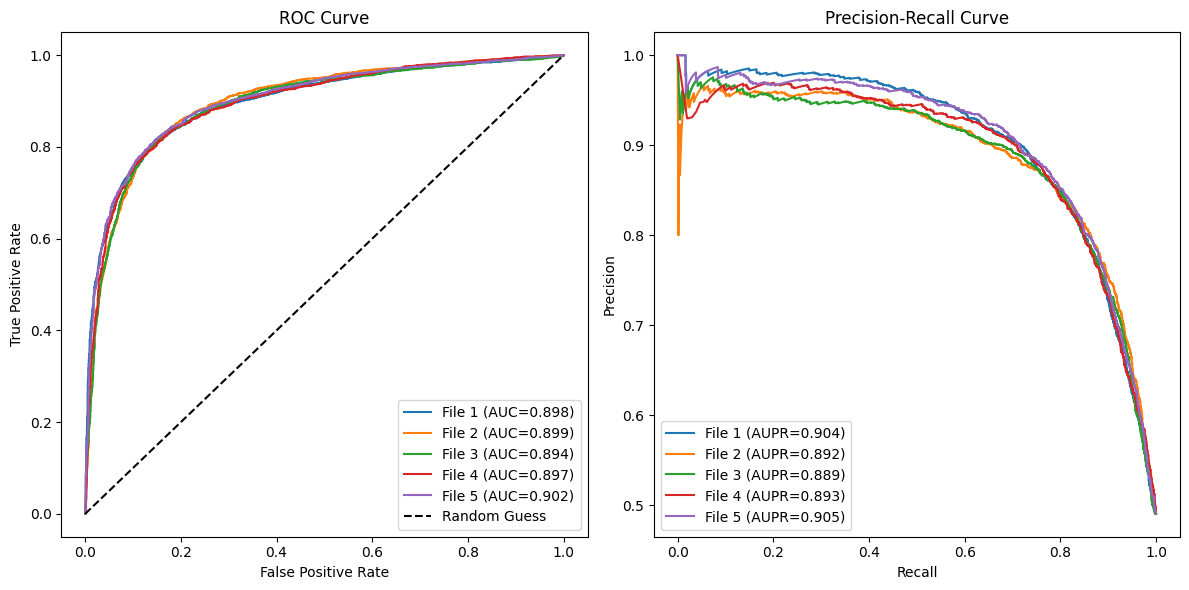

In [5]:
# 主程序
file_paths = [
    './scaffold_RUN_1/test_prediction_seed3.csv',
    './scaffold_RUN_2/test_prediction_seed3.csv',
    './scaffold_RUN_3/test_prediction_seed3.csv',
    './scaffold_RUN_4/test_prediction_seed3.csv',
    './scaffold_RUN_5/test_prediction_seed3.csv'
]  # 替换为实际文件路径
results = []

# 存储每次运行的指标
auc_list = []
aupr_list = []
f1_list = []
accuracy_list = []
precision_list = []
recall_list = []
mcc_list = []

for file_path in file_paths:
    result = calculate_metrics(file_path)
    results.append(result)
    
    # 提取指标
    auc_list.append(result['auc'])
    aupr_list.append(result['aupr'])
    f1_list.append(result['best_metrics']['f1'])
    accuracy_list.append(result['best_metrics']['accuracy'])
    precision_list.append(result['best_metrics']['precision'])
    recall_list.append(result['best_metrics']['recall'])
    mcc_list.append(result['best_metrics']['mcc'])
    
    # 打印每次运行的结果
    print(f"Results for {file_path}:")
    print(f"AUC: {result['auc']:.4f}, AUPR: {result['aupr']:.4f}")
    print(f"Best Threshold: {result['best_threshold']:.4f}")
    print(f"Metrics at Best Threshold: {result['best_metrics']}")
    print()

# 计算均值和标准差
metrics_summary = {
    'AUC': (np.mean(auc_list), np.std(auc_list)),
    'AUPR': (np.mean(aupr_list), np.std(aupr_list)),
    'F1': (np.mean(f1_list), np.std(f1_list)),
    'Accuracy': (np.mean(accuracy_list), np.std(accuracy_list)),
    'Precision': (np.mean(precision_list), np.std(precision_list)),
    'Recall': (np.mean(recall_list), np.std(recall_list)),
    'MCC': (np.mean(mcc_list), np.std(mcc_list))
}

# 打印均值和标准差
print("\nSummary of Metrics (Mean ± Std):")
for metric, (mean, std) in metrics_summary.items():
    print(f"{metric}: {mean:.4f} ± {std:.4f}")

# 绘制曲线
plot_curves(results, 'roc_pr_curves.png')

## scaffold_protein

Results for ./scaffold_protein_RUN_1/test_prediction_seed3.csv:
AUC: 0.7727, AUPR: 0.7837
Best Threshold: 0.1041
Metrics at Best Threshold: {'accuracy': 0.6726814939152329, 'f1': 0.7132352941176471, 'precision': 0.6209987195902689, 'recall': 0.8376511226252159, 'mcc': 0.37272331718424073, 'tp': 970, 'tn': 633, 'fp': 592, 'fn': 188}

Results for ./scaffold_protein_RUN_2/test_prediction_seed3.csv:
AUC: 0.7670, AUPR: 0.7758
Best Threshold: 0.3013
Metrics at Best Threshold: {'accuracy': 0.697859840537138, 'f1': 0.7056418642681929, 'precision': 0.6700310559006211, 'recall': 0.7452504317789291, 'mcc': 0.3994664856329051, 'tp': 863, 'tn': 800, 'fp': 425, 'fn': 295}

Results for ./scaffold_protein_RUN_3/test_prediction_seed3.csv:
AUC: 0.7725, AUPR: 0.7851
Best Threshold: 0.3023
Metrics at Best Threshold: {'accuracy': 0.6898866974402015, 'f1': 0.7114408434205388, 'precision': 0.6493228795438346, 'recall': 0.7867012089810017, 'mcc': 0.39112763949370405, 'tp': 911, 'tn': 733, 'fp': 492, 'fn': 247

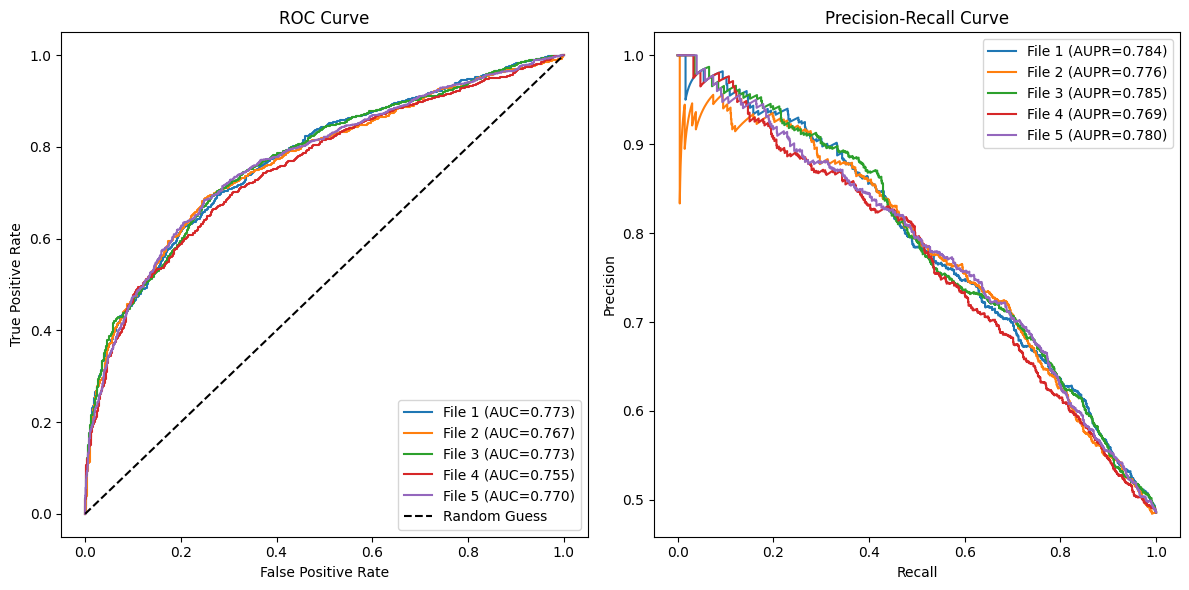

In [6]:
# 主程序
file_paths = [
    './scaffold_protein_RUN_1/test_prediction_seed3.csv',
    './scaffold_protein_RUN_2/test_prediction_seed3.csv',
    './scaffold_protein_RUN_3/test_prediction_seed3.csv',
    './scaffold_protein_RUN_4/test_prediction_seed3.csv',
    './scaffold_protein_RUN_5/test_prediction_seed3.csv'
]  # 替换为实际文件路径
results = []

# 存储每次运行的指标
auc_list = []
aupr_list = []
f1_list = []
accuracy_list = []
precision_list = []
recall_list = []
mcc_list = []

for file_path in file_paths:
    result = calculate_metrics(file_path)
    results.append(result)
    
    # 提取指标
    auc_list.append(result['auc'])
    aupr_list.append(result['aupr'])
    f1_list.append(result['best_metrics']['f1'])
    accuracy_list.append(result['best_metrics']['accuracy'])
    precision_list.append(result['best_metrics']['precision'])
    recall_list.append(result['best_metrics']['recall'])
    mcc_list.append(result['best_metrics']['mcc'])
    
    # 打印每次运行的结果
    print(f"Results for {file_path}:")
    print(f"AUC: {result['auc']:.4f}, AUPR: {result['aupr']:.4f}")
    print(f"Best Threshold: {result['best_threshold']:.4f}")
    print(f"Metrics at Best Threshold: {result['best_metrics']}")
    print()

# 计算均值和标准差
metrics_summary = {
    'AUC': (np.mean(auc_list), np.std(auc_list)),
    'AUPR': (np.mean(aupr_list), np.std(aupr_list)),
    'F1': (np.mean(f1_list), np.std(f1_list)),
    'Accuracy': (np.mean(accuracy_list), np.std(accuracy_list)),
    'Precision': (np.mean(precision_list), np.std(precision_list)),
    'Recall': (np.mean(recall_list), np.std(recall_list)),
    'MCC': (np.mean(mcc_list), np.std(mcc_list))
}

# 打印均值和标准差
print("\nSummary of Metrics (Mean ± Std):")
for metric, (mean, std) in metrics_summary.items():
    print(f"{metric}: {mean:.4f} ± {std:.4f}")

# 绘制曲线
plot_curves(results, 'roc_pr_curves.png')